# PCA and SVM Decomposition

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rodolfomendes/abalone-dataset")

print("Path to dataset files:", path)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 57.3k/57.3k [00:00<00:00, 37.5MB/s]

Extracting files...
Path to dataset files: /Users/ethanhersch/.cache/kagglehub/datasets/rodolfomendes/abalone-dataset/versions/3


In [5]:
import os

for file in os.listdir(path):
    print(file)

file_path = os.path.join(path, "abalone.csv")

abalone.csv


In [7]:
import pandas as pd
df = pd.read_csv(file_path)

print(df.head())
print(df.shape)
print(df.columns)

  Sex  Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  
(4177, 9)
Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')


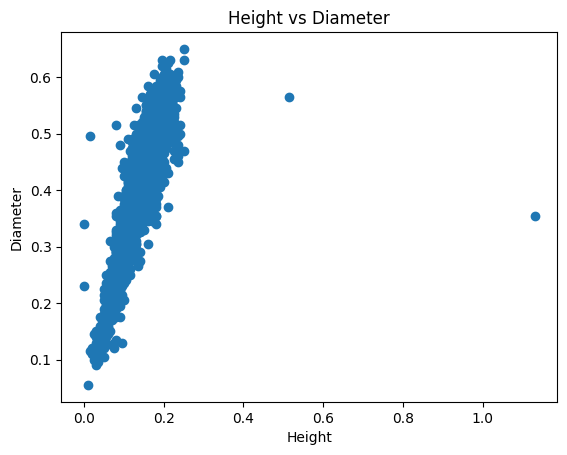

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["Height"], df["Diameter"])
plt.title("Height vs Diameter")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.show()

## We can already see for the height vs diameter plot, this data can already be reduced to 1-D

In [16]:
import numpy as np

## convert to np matrix
X = df[["Height", "Diameter"]].to_numpy()

print(X.shape)
print(X[:5])

(4177, 2)
[[0.095 0.365]
 [0.09  0.265]
 [0.135 0.42 ]
 [0.125 0.365]
 [0.08  0.255]]


### PCA Step 1: Center mean data

In [17]:
# column-wise mean
mu_x, mu_y = np.mean(X, axis=0)

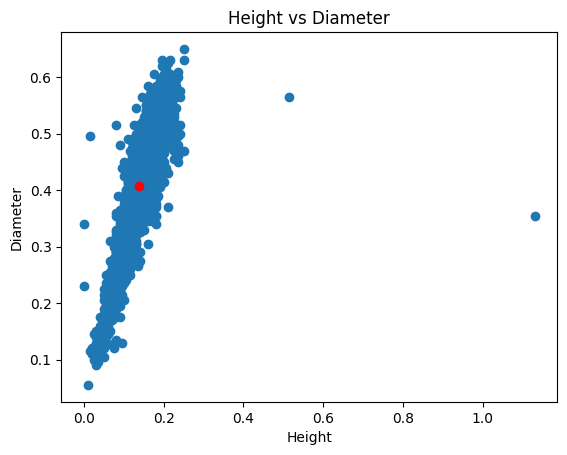

In [19]:
plt.scatter(df["Height"], df["Diameter"])
plt.scatter(mu_x, mu_y, color='red')
plt.title("Height vs Diameter")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.show()

In [20]:
X_normalized = X - [mu_x, mu_y]

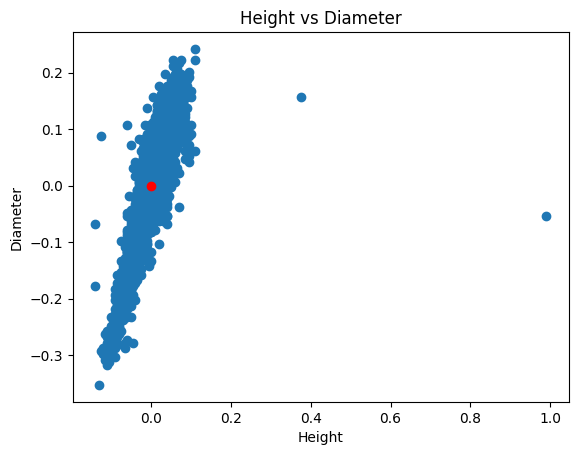

In [24]:
plt.scatter(X_normalized[:, 0], X_normalized[:, 1])
plt.scatter(0, 0, color='red')
plt.title("Height vs Diameter")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.show()

__Now we can see `X_normalized` has 0 mean__

## Compute covariance matrix

$$cov(x, y) = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{n} = \frac{1}{n} X_{normalized}^T Y_{normalized}$$

In [44]:
N, d = X_normalized.shape
cov_mat = X_normalized.T @ X_normalized / N # this is the variance of x
cov_mat

array([[0.00174908, 0.00345972],
       [0.00345972, 0.00984619]])

## Now decompose the variance

> Can do power iteration, but just use SciPy eig here

In [45]:
from scipy import linalg

results = linalg.eig(cov_mat)

In [46]:
results

(array([0.00047219+0.j, 0.01112309+0.j]),
 array([[-0.93814373, -0.34624608],
        [ 0.34624608, -0.93814373]]))

In [47]:
w, v = results
eigenvector_1 = v[:, 0]
eigenvector_1

array([-0.93814373,  0.34624608])

In [52]:
eigenvector_2 = v[:, 1]

In [50]:
pc_1 = X_normalized @ eigenvector_1
pc_1

array([ 0.02691531, -0.00301858,  0.0084331 , ..., -0.03819343,
        0.01686694, -0.0011123 ], shape=(4177,))

_This is how we get the projection onto each component_

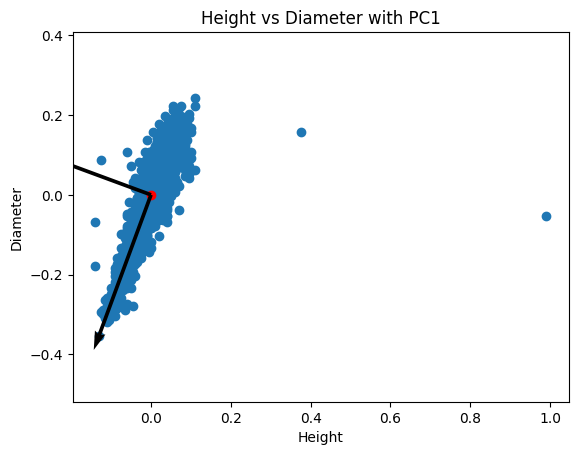

In [53]:
plt.scatter(X_normalized[:, 0], X_normalized[:, 1])

# origin
plt.scatter(0, 0, color='red')

# plot PC1 direction
plt.quiver(
    0, 0,
    eigenvector_1[0],
    eigenvector_1[1],
    scale=3
)

plt.quiver(
    0, 0,
    eigenvector_2[0],
    eigenvector_2[1],
    scale=3
)

plt.title("Height vs Diameter with PC1")
plt.xlabel("Height")
plt.ylabel("Diameter")
plt.axis("equal")
plt.show()

__Both eigenvectors are plotted. Notice how the highest variance component is "up-left" vector. This is because of these noisy outliers.__

## Change coordinates by projecting onto `eigenvector_2`

In [65]:
V = np.column_stack((eigenvector_2, eigenvector_1))
Z = X_normalized @ V
Z

array([[ 0.05564241,  0.02691531],
       [ 0.15118801, -0.00301858],
       [-0.00980534,  0.0084331 ],
       ...,
       [-0.08564047, -0.03819343],
       [-0.07597837,  0.01686694],
       [-0.15722951, -0.0011123 ]], shape=(4177, 2))

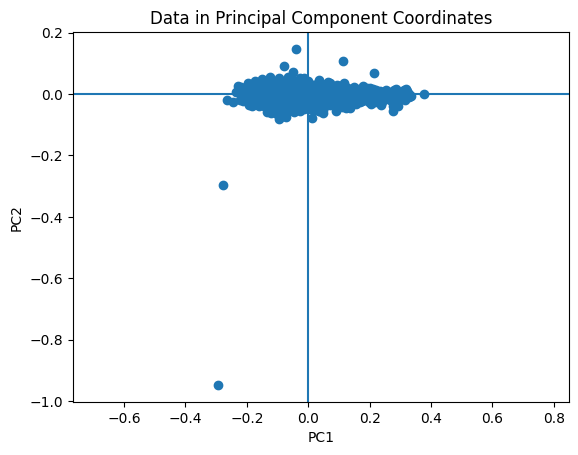

In [66]:
plt.scatter(Z[:, 0], Z[:, 1])

plt.axhline(0)
plt.axvline(0)

plt.title("Data in Principal Component Coordinates")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.axis("equal")
plt.show()